In [16]:
import pandas as pd
import seaborn as sns
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('malware_dacrank1_xhour.csv', index_col=0)
df['hour'] = df['hour'].astype(int)
df.head()

,day,hour,dac_family,qr,r,nx,dn_rank_1,wl_rank_le4,u,u_wl_rank_le4,u_dn_rank_1
0,0,10,virut,23,12,0,23,0,1,0,1
1,0,11,virut,1,0,0,1,0,1,0,1
2,0,18,healthy,1664600,749380,51621,1620842,532254,54218,4325,51601
3,0,9,modpack,31,15,0,31,0,1,0,1
4,0,9,necurs,24470,6202,11349,24470,0,1996,0,1996


In [2]:

import itertools


day = list(range(10))
hours = list(range(24))
dac_families = df.dac_family.drop_duplicates()
cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4',
       'u', 'u_wl_rank_le4', 'u_dn_rank_1']

values = []
for a, b, c in itertools.product(day, hours, dac_families):
    values.append([a,b,c] + [0 for _ in range(len(cols))])

df0 = pd.DataFrame(data=values, columns=df.columns)

# pd.merge(df, right=df0, left_on=['day','dac_family'], right_on=['day','dac_family'], how='left')
DF = pd.concat([df, df0]).drop_duplicates(subset=['day', 'hour', 'dac_family']).sort_values(by=['day', 'hour', 'dac_family']).reset_index(drop=True)

DF = DF[DF.hour < 24]

DF['hourx'] = DF['day'] * 24 + DF['hour']

DF

,day,hour,dac_family,qr,r,nx,dn_rank_1,wl_rank_le4,u,u_wl_rank_le4,u_dn_rank_1,hourx
0,0,0,conficker,0,0,0,0,0,0,0,0,0
1,0,0,healthy,1675878,803235,47326,1636413,529790,56058,4386,53408,0
2,0,0,modpack,31,14,0,31,0,1,0,1,0
3,0,0,necurs,68737,19199,31184,68737,0,4005,0,4005,0
4,0,0,pitou,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1932,9,23,necurs,76868,21671,37299,76868,0,5981,0,5981,239
1933,9,23,pitou,4531,461,3170,4531,0,18,0,18,239
1934,9,23,suppobox,0,0,0,0,0,0,0,0,239
1935,9,23,tofsee,0,0,0,0,0,0,0,0,239


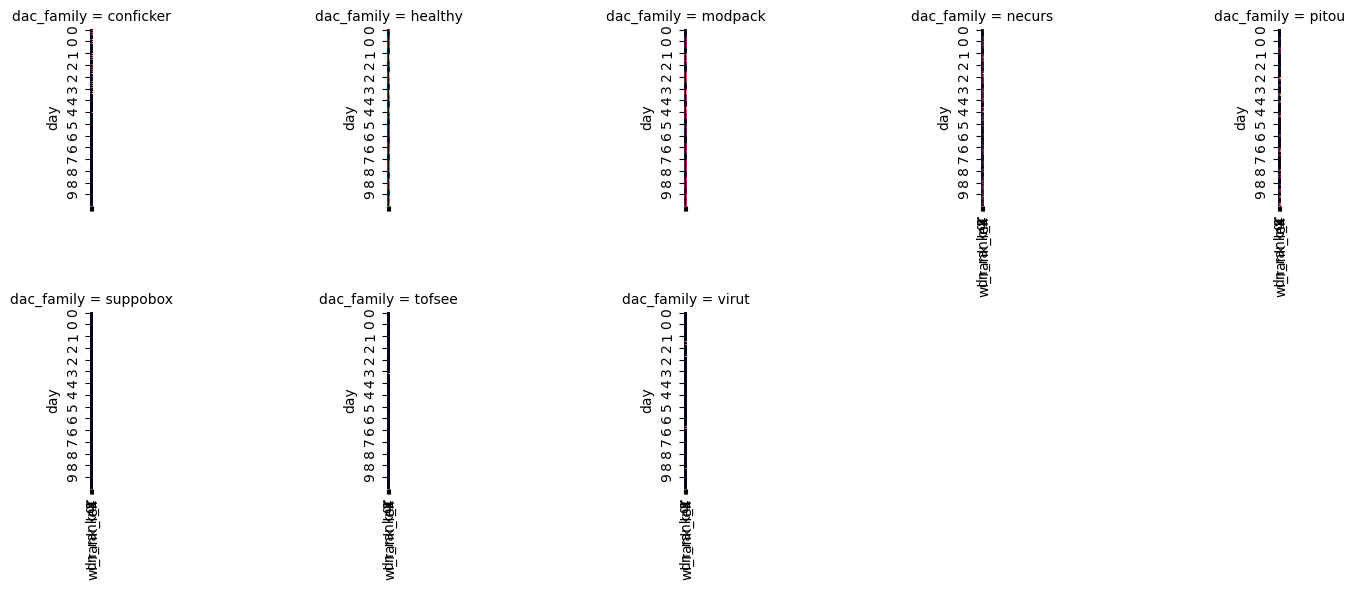

In [3]:
from matplotlib import pyplot as plt

cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4']

DF_ALL = pd.melt(DF, id_vars=['hourx', 'dac_family'], value_vars=cols, value_name='value')

def draw_heatmap(*args, **kwargs):
    df = kwargs.pop('data')
    sns.heatmap(df.set_index('day')[cols], **kwargs)

fg = sns.FacetGrid(DF, col='dac_family', col_wrap=5, sharex=True, sharey=False)

fg.map_dataframe(draw_heatmap, cbar=False, square = True)
plt.show()

In [21]:
import math
from typing import cast

from matplotlib.axes import Axes
import matplotlib.colors as mcolors

import numpy as np

nrows =8
ncols=1
fig, axs = plt.subplots(nrows, ncols, figsize=(6, 8), sharey=True)
axs = cast(np.ndarray, axs)

dac_families = sorted(DF.dac_family.drop_duplicates())
dac_families.remove('healthy')
dac_families.insert(0, 'healthy')

cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4']
for idxmw, mw in enumerate(dac_families):
    row = math.floor(idxmw / ncols)
    col = idxmw % ncols

    DFMW = DF[DF.dac_family == mw].set_index('hourx')[cols]

    if DFMW['qr'].mean() > 1000:
        cmap = sns.dark_palette("#f74", reverse=False, as_cmap=True)
    else:
        cmap = sns.dark_palette("#69d", reverse=False, as_cmap=True)
        pass

    ax = cast(Axes, axs[row])
    # ax = cast(Axes, axs[row, col])

    sns.heatmap(
        DFMW.T,
        annot=False,
        ax=ax,
        square=False,
        cbar_kws={'fraction': 0.05, 'aspect':10},
        cmap=cmap,
        mask=DFMW.T == 0,
        linewidths=0.00001    
    )
    ax.set_xlabel('')
    ax.set_xticks(list(range(12,240,24)), map(str, range(1,11)))
    
    for day in range(24,240,24):
        ax.axvline(day, c='white', lw=0.5)
    
    ax.axhline(1, c='white', lw=2)
    ax.axhline(2, c='white', lw=2)
    ax.axhline(3, c='white', lw=2)
    ax.axhline(4, c='white', lw=2)

    ax.set_title(mw)
    ax.redraw_in_frame()
    pass

fig.tight_layout(h_pad = 1, w_pad=0)
